In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# FILE_PATH = '/Users/jplatta/.tickrake/data/options/massive/SPXW_exp2023-09-26_2023-09-26_13-30-00.csv'
FILE_PATH = (
    "/Users/jplatta/.tickrake/data/options/massive/SPXW_exp2023-09-26_2023-09-26_14-19-00.csv"
)

In [16]:
data = pd.read_csv(FILE_PATH, header=0)

In [17]:
calls_df = data.loc[data["contract_type"] == "CALL"].reset_index(drop=True)
puts_df = data.loc[data["contract_type"] == "PUT"].reset_index(drop=True)

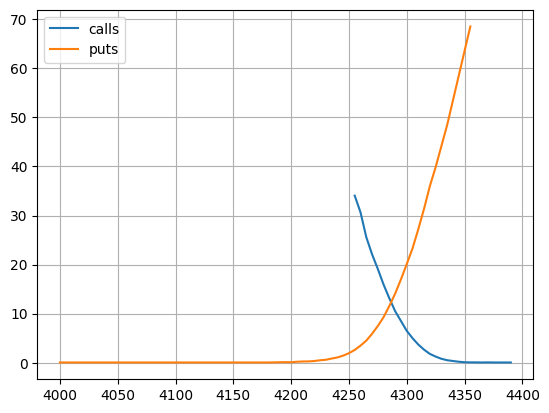

In [20]:
plt.figure()
plt.plot(calls_df["strike"], calls_df["open"], label="calls")
plt.plot(puts_df["strike"], puts_df["open"], label="puts")
plt.grid(True)
plt.legend()

In [118]:
massive_opt_chain_df = pd.read_csv(
    "/Users/jplatta/repos/options_trader/option_chain_SPXW_20260504094140.csv", header=0
)

In [119]:
massive_opt_chain_df.head()

,symbol,underlying_symbol,underlying_price,expiration_date,strike,contract_type,mark,bid,ask,delta,gamma,theta,vega,rho,open_interest,total_volume,volatility
0,SPXW241016C03210000,SPX,5841.88,2024-10-16,3210.0,CALL,2631.88,2631.855,2631.905,1.0,0.0,-0.0,0.0,10.436345,0,0,17.4547
1,SPXW241016C03215000,SPX,5841.88,2024-10-16,3215.0,CALL,2626.88,2626.855,2626.905,1.0,0.0,-0.0,0.0,10.452601,0,0,17.4547
2,SPXW241016C03220000,SPX,5841.88,2024-10-16,3220.0,CALL,2621.88,2621.855,2621.905,1.0,0.0,-0.0,0.0,10.468857,0,0,17.4547
3,SPXW241016C03225000,SPX,5841.88,2024-10-16,3225.0,CALL,2616.88,2616.855,2616.905,1.0,0.0,-0.0,0.0,10.485113,0,0,17.4547
4,SPXW241016C03230000,SPX,5841.88,2024-10-16,3230.0,CALL,2611.88,2611.855,2611.905,1.0,0.0,-0.0,0.0,10.501369,0,0,17.4547


In [120]:
syn_opt_ch.head()

,symbol,underlying_symbol,underlying_price,expiration_date,strike,contract_type,mark,bid,ask,delta,gamma,theta,vega,rho,open_interest,total_volume,volatility
0,SPXW241016C03210000,SPX,5841.88,2024-10-16,3210.0,CALL,2631.88,2631.855,2631.905,1.0,0.0,-0.0,0.0,10.436345,0,0,17.4547
1,SPXW241016C03215000,SPX,5841.88,2024-10-16,3215.0,CALL,2626.88,2626.855,2626.905,1.0,0.0,-0.0,0.0,10.452601,0,0,17.4547
2,SPXW241016C03220000,SPX,5841.88,2024-10-16,3220.0,CALL,2621.88,2621.855,2621.905,1.0,0.0,-0.0,0.0,10.468857,0,0,17.4547
3,SPXW241016C03225000,SPX,5841.88,2024-10-16,3225.0,CALL,2616.88,2616.855,2616.905,1.0,0.0,-0.0,0.0,10.485113,0,0,17.4547
4,SPXW241016C03230000,SPX,5841.88,2024-10-16,3230.0,CALL,2611.88,2611.855,2611.905,1.0,0.0,-0.0,0.0,10.501369,0,0,17.4547


In [126]:
# syn_opt_ch = pd.read_csv('./data/synthetic_opt_chain.csv', header=0)
syn_opt_ch = pd.read_csv(
    "/Users/jplatta/repos/options_trader/option_chain_SPXW_20260504121025.csv", header=0
)
syn_calls = syn_opt_ch[
    (syn_opt_ch["contract_type"] == "CALL")
    & (syn_opt_ch["strike"] > 5600)
    & (syn_opt_ch["strike"] < 6000)
]
syn_puts = syn_opt_ch[
    (syn_opt_ch["contract_type"] == "PUT")
    & (syn_opt_ch["strike"] < 6000)
    & (syn_opt_ch["strike"] > 5600)
]

In [127]:
syn_puts.iloc[0].underlying_price

np.float64(5841.88)

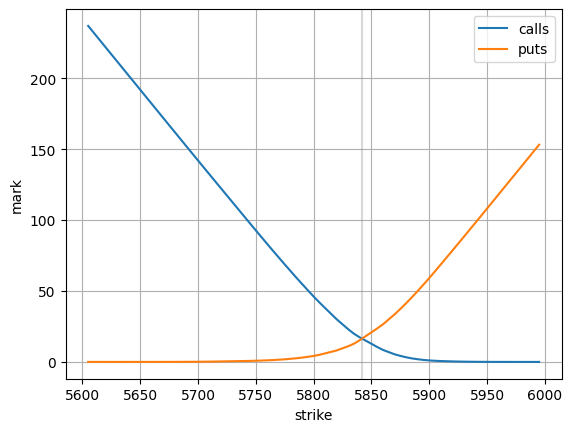

In [128]:
plt.figure()
plt.plot(syn_calls["strike"], syn_calls["mark"], label="calls")
plt.plot(syn_puts["strike"], syn_puts["mark"].abs(), label="puts")
plt.axvline(syn_puts.iloc[0].underlying_price, c="gray", alpha=0.3)
plt.ylabel("mark")
plt.xlabel("strike")
plt.grid(True)
plt.legend()

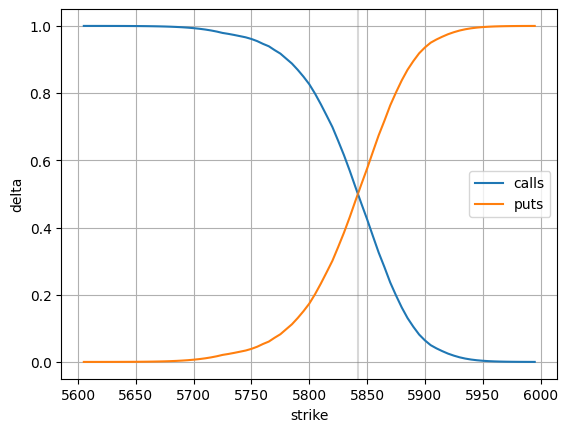

In [129]:
plt.figure()
plt.plot(syn_calls["strike"], syn_calls["delta"], label="calls")
plt.plot(syn_puts["strike"], syn_puts["delta"].abs(), label="puts")
plt.axvline(syn_puts.iloc[0].underlying_price, c="gray", alpha=0.3)
plt.ylabel("delta")
plt.xlabel("strike")
plt.grid(True)
plt.legend()

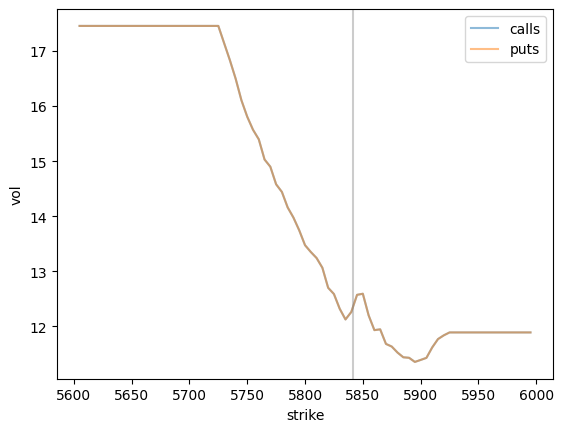

In [130]:
plt.figure()
plt.plot(syn_calls["strike"], syn_calls["volatility"], label="calls", alpha=0.5)
plt.plot(syn_puts["strike"], syn_puts["volatility"], label="puts", alpha=0.5)
plt.axvline(syn_puts.iloc[0].underlying_price, c="gray", alpha=0.4)
# plt.grid(True)
plt.ylabel("vol")
plt.xlabel("strike")
plt.legend()